In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path
from audiotools import AudioSignal #for playback

import text2fx
from text2fx.apply import main as apply 
from text2fx.applybatch import main as applybatch
from text2fx.applyFXparams import apply_fx_to_sig as applyFX

In [2]:
text2fx?

Type:        module
String form: <module 'text2fx' from '/home/annie/research/text2fx/text2fx/__init__.py'>
File:        ~/research/text2fx/text2fx/__init__.py
Docstring:   <no docstring>

In [3]:
!pip3 install muq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 132.5 kB/s eta 0:00:0031m14.3 MB/s eta 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 148.2 kB/s eta 0:00:00MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 91.1 kB/s eta 0:00:0031m70.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.6 MB/s eta 0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.0 MB/s eta 0:00:000m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 93.6 kB/s eta 0:00:0031m74.5 MB/s eta 0:00:01
  Created wheel for muq: filename=muq-0.1.0-py3-none-any.whl size=60108 sha256=02dc114d3f66979a296abc101b51e46f468b3f1845812c0c527692b236c13012
  Stored in directory: /home/annie/.cache/pip/wheels/7a/1f/75/0d85761259a3ab5dad53befa195dd29ad6850306917081e8bb
Successfully built muq



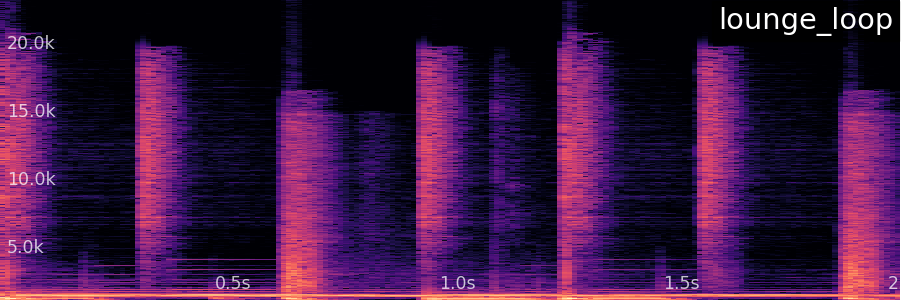
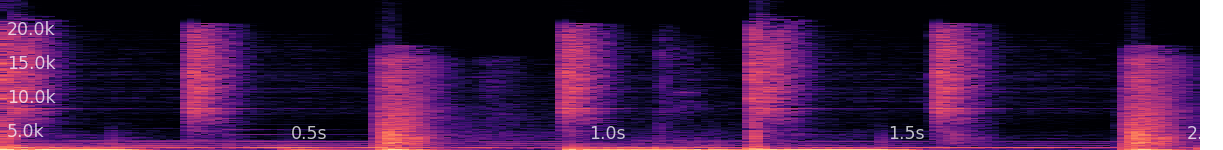

In [47]:
audio_path = Path('/home/annie/research/text2fx/assets/lounge_loop.wav')
AudioSignal(audio_path).widget(f'{audio_path.stem}') # play input sound

In [93]:
from typing import List
from pathlib import Path

def get_mulan_text_embeds(text: List[str]):
    with torch.no_grad():
        text_embeds = mulan(texts = text)
    return text_embeds

# def get_mulan_audio_embeds(audio: Path, sr=2400):
#     wav, sr = librosa.load(audio, sr = sr) #NOTE: how much does sample rate affect it?
#     wavs = torch.tensor(wav).unsqueeze(0).to(device) 
#     with torch.no_grad():
#         audio_embeds = mulan(wavs = wavs)
#         print(audio_embeds[0][:10])
#     return audio_embeds

def get_mulan_audio_embeds(audio: Path, sr=44100):
    sig = AudioSignal(audio).to_mono().resample(sr)
    sig_samples = sig.samples.squeeze(0).to(device)
    with torch.no_grad():
        audio_embeds = mulan(wavs = sig_samples)
        # print(audio_embeds[0][:10])
    return audio_embeds


def calc_sim(audio_embeds, text_embeds, method: str="cos"):
    if method=="cos":
        return torch.cosine_similarity(audio_embeds, text_embeds, dim=-1) #regular cosine-sim
    elif method=="mulan":
        return mulan.calc_similarity(audio_embeds, text_embeds) #dot product
    elif method=="clap":
        return clap_model.compute_similarity(audio_embeds, text_embeds)  #clap's cosine_sim w/ learnable parameter

#testing
texts = ["lounge loop", "a snazzy lounge loop", "happy"]
t_embeds = get_mulan_text_embeds(texts)
    
audio_path = Path('/home/annie/research/text2fx/assets/lounge_loop.wav')
a_embeds = get_mulan_audio_embeds(audio_path, 44100)
a_embeds = get_mulan_audio_embeds(audio_path, 2400)

In [51]:
import torch, librosa
from muq import MuQMuLan

# This will automatically fetch checkpoints from huggingface
device = 'cuda'
mulan = MuQMuLan.from_pretrained("OpenMuQ/MuQ-MuLan-large")
mulan = mulan.to(device).eval()

# Extract music embeddings
wav, sr = librosa.load(audio_path, sr = 44100) #NOTE: how much does sample rate affect it?
wav, sr = librosa.load(audio_path, sr = 2400) #NOTE: how much does sample rate affect it?
# wav, sr = librosa.load("path/to/music_audio.wav", sr = 24000)
wavs = torch.tensor(wav).unsqueeze(0).to(device) 

print("LIBROSA")
print(wavs)
print(wavs.shape, sr)

print("\naudiosignal")
sig = AudioSignal(audio_path).resample(2400).to_mono()
sig_samples = sig.samples.squeeze(0) #same as torch.tensor(wav).unsqueeze(0).to(device) 
# sig.resample(2400).widget()
print(sig.samples)
print(sig.samples.shape)
print(sig.samples.squeeze(0))
print(sig.samples.squeeze(0).shape, sr)

# with torch.no_grad():
#     audio_embeds = mulan(wavs = wavs) 

# # Extract text embeddings (texts can be in English or Chinese)
# texts = ["classical genres, hopeful mood, piano.", "guitar", "bright guitar", "piano"]
# with torch.no_grad():
#     text_embeds = mulan(texts = texts)

# # Calculate dot product similarity
# sim = mulan.calc_similarity(audio_embeds, text_embeds)
# print(sim)

# print(torch.cosine_similarity(audio_embeds, text_embeds, dim=-1)) #regular cosine-sim


LIBROSA
tensor([[-0.0082,  0.0335,  0.3208,  ..., -0.0844, -0.1438,  0.0000]],
       device='cuda:0')
torch.Size([1, 4814]) 2400

audiosignal
tensor([[[-0.0235,  0.0378,  0.3182,  ...,  0.0058, -0.0893, -0.1349]]])
torch.Size([1, 1, 4813])
tensor([[-0.0235,  0.0378,  0.3182,  ...,  0.0058, -0.0893, -0.1349]])
torch.Size([1, 4813]) 2400


In [25]:
print(audio_embeds.shape)
print(text_embeds.shape)

torch.Size([1, 512])
torch.Size([4, 512])


In [35]:
from msclap import CLAP

# Load model (Choose between versions '2022' or '2023')
# The model weight will be downloaded automatically if `model_fp` is not specified
clap_model = CLAP(version = '2023', use_cuda=False)

# Extract text embeddings
texts = ["classical genres, hopeful mood, piano.", "guitar", "bright guitar", "piano"]
text_embeddings = clap_model.get_text_embeddings(texts)
# print(text_embeddings)
# print(text_embeddings.shape)

# Extract audio embeddings
audio_embeddings = clap_model.get_audio_embeddings([str(audio_path)])
# print(audio_embeddings.shape)

# Compute similarity between audio and text embeddings; clap embeddings
print("CLAP")
similarities = clap_model.compute_similarity(audio_embeddings, text_embeddings)  #clap's cosine_sim w/ learnable parameter
print(similarities) # NOTE: is it better to use clap's compute similarity 

# clap similarity on mulan embeddings
print("MULAN")
# print(clap_model.compute_similarity(audio_embeds, text_embeds)) #clap's cosine_sim w/ learnable parameter
print(torch.cosine_similarity(audio_embeds, text_embeds, dim=-1)) #regular cosine-sim


CLAP
tensor([[10.3381,  4.6021,  1.8686,  5.0948]], grad_fn=<PermuteBackward0>)
MULAN
tensor([-0.2278,  0.1833,  0.0006,  0.1468], device='cuda:0')


### hhh

### Experiment 1: How well do different embeddings actually capture semantics?
- Take a "regular" guitar riff, take the certified "bright" version; take audio embeddings. Measure similarity.
- Vary Similarity metric (reg cosine vs clap)
- Vary promtp engineering -- what get's prepended to the text prepended-text
- Vary cross-modal embedder (mulan vs clap)


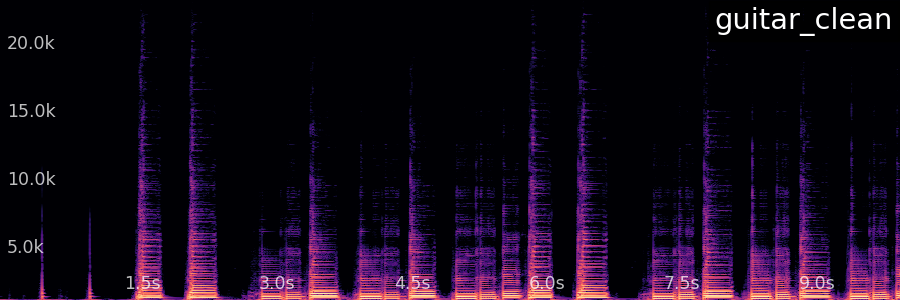
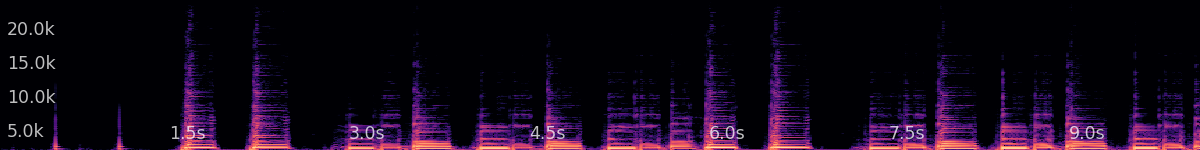


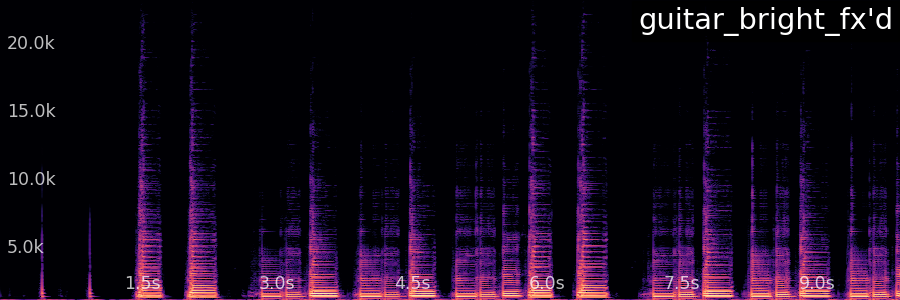
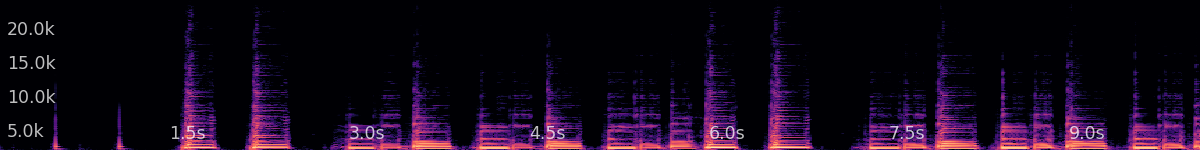


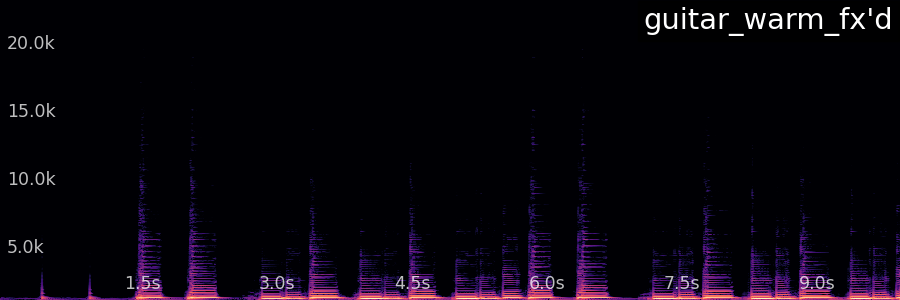
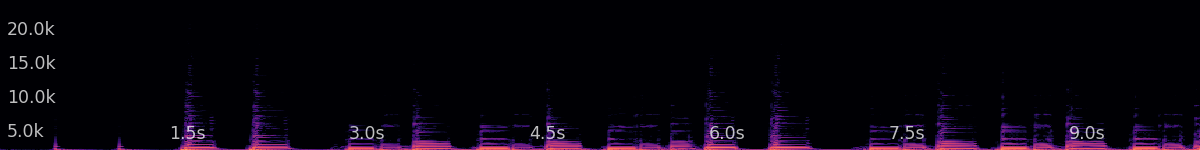


CLAP=======
clean sig ('a guitar riff') --> similarity to 'a guitar' vs similarity to a bright, guitar vs similarity to a warm guitar that is very much not bright
tensor([0.2716, 0.2073, 0.3880])
tensor([[ 9.0646,  6.9211, 12.9506]], grad_fn=<PermuteBackward0>)

 fx'd sig ('a bright guitar riff') --> similarity to 'a guitar' vs similarity to a bright, guitarvs similarity to a warm guitar that is very much not bright
tensor([0.2663, 0.2270, 0.3444])
tensor([[ 8.8906,  7.5781, 11.4944]], grad_fn=<PermuteBackward0>)

 OPP fx'd sig ('a warm guitar riff')--> similarity to 'a guitar' vs similarity to a bright, guitar vs similarity to a warm guitar that is very much not bright
tensor([0.2113, 0.1231, 0.2727])
tensor([[7.0532, 4.1095, 9.1042]], grad_fn=<PermuteBackward0>)

MULAN=======SR166
clean sig ('a guitar riff') --> similarity to 'a guitar' vs similarity to a bright, guitar vs similarity to a warm guitar that is very much not bright
tensor([0.4403, 0.2972, 0.2355], device='cuda:0')
tens

In [117]:

# audio_path = Path('/home/annie/research/text2fx/assets/guitar.wav')
INSTRUMENT = 'guitar'
TEXT_TARGET = 'bright'
OPP_TARGET = 'warm'

# SETTING SIGNAL PATHS
audio_path = Path(f'/home/annie/research/text2fx/assets/multistem_examples/10s/{INSTRUMENT}.wav')
clean_audio_sig = AudioSignal(audio_path).to_mono().resample(44_100).ensure_max_of_audio()
clean_audio_sig.widget(title=f"{INSTRUMENT}_clean")

fxd_audio_path = Path(f'/home/annie/research/text2fx/assets/multistem_examples/audealize_generated/EQ/{INSTRUMENT}/{TEXT_TARGET}.wav')
fxd_audio_sig = AudioSignal(fxd_audio_path).to_mono().resample(44_100).ensure_max_of_audio()
fxd_audio_sig.widget(title=f"{INSTRUMENT}_{TEXT_TARGET}_fx'd")

fxd_opp_audio_path = Path(f'/home/annie/research/text2fx/assets/multistem_examples/audealize_generated/EQ/{INSTRUMENT}/{OPP_TARGET}.wav')
fxd_opp_audio_sig = AudioSignal(fxd_opp_audio_path).to_mono().resample(44_100).ensure_max_of_audio()
fxd_opp_audio_sig.widget(title=f"{INSTRUMENT}_{OPP_TARGET}_fx'd")

# MGETTING EMBEDDINGS
texts = [f'a {INSTRUMENT}', f'a {TEXT_TARGET}, {INSTRUMENT}', f'a {OPP_TARGET} {INSTRUMENT} that is very much not {TEXT_TARGET}']
# texts = ['this is the sound of ' + x for x in texts]

#CLAP embeddings
print("\nCLAP=======")
text_embeddings = clap_model.get_text_embeddings(texts)
clean_audio_embed_clap = clap_model.get_audio_embeddings([str(audio_path)])
fxd_audio_embed_clap = clap_model.get_audio_embeddings([str(fxd_audio_path)])
fxd_opp_audio_embed_clap = clap_model.get_audio_embeddings([str(fxd_opp_audio_path)])

print(f"clean sig ('a guitar riff') --> similarity to '{texts[0]}' vs similarity to {texts[1]} vs similarity to {texts[2]}")
print(calc_sim(clean_audio_embed_clap, text_embeddings, "cos"))
print(calc_sim(clean_audio_embed_clap, text_embeddings, "clap"))

print(f"\n fx'd sig ('a {TEXT_TARGET} guitar riff') --> similarity to '{texts[0]}' vs similarity to {texts[1]}vs similarity to {texts[2]}")
print(calc_sim(fxd_audio_embed_clap, text_embeddings, "cos"))
print(calc_sim(fxd_audio_embed_clap, text_embeddings, "clap"))

print(f"\n OPP fx'd sig ('a {OPP_TARGET} guitar riff')--> similarity to '{texts[0]}' vs similarity to {texts[1]} vs similarity to {texts[2]}")
print(calc_sim(fxd_opp_audio_embed_clap, text_embeddings, "cos"))
print(calc_sim(fxd_opp_audio_embed_clap, text_embeddings, "clap"))


print("\nMULAN=======SR166")
# #mulan embeddings
SR=16_000
text_embeddings_mulan = get_mulan_text_embeds(texts)
clean_audio_embed_mulan =get_mulan_audio_embeds(audio_path, SR)# clap_model.get_audio_embeddings([str(audio_path))
fxd_audio_embed_mulan = get_mulan_audio_embeds(fxd_audio_path, SR)
fxd_opp_audio_embed_mulan = get_mulan_audio_embeds(fxd_opp_audio_path, SR)

print(f"clean sig ('a guitar riff') --> similarity to '{texts[0]}' vs similarity to {texts[1]} vs similarity to {texts[2]}")
print(calc_sim(clean_audio_embed_mulan, text_embeddings_mulan, "cos"))
print(calc_sim(clean_audio_embed_mulan, text_embeddings_mulan, "mulan"))

print(f"\n fx'd sig ('a {TEXT_TARGET} guitar riff') --> similarity to '{texts[0]}' vs similarity to {texts[1]}vs similarity to {texts[2]}")
print(calc_sim(fxd_audio_embed_mulan, text_embeddings_mulan, "cos"))
print(calc_sim(fxd_audio_embed_mulan, text_embeddings_mulan, "mulan"))

print(f"\n OPP fx'd sig ('a {OPP_TARGET} guitar riff')--> similarity to '{texts[0]}' vs similarity to {texts[1]} vs similarity to {texts[2]}")
print(calc_sim(fxd_opp_audio_embed_mulan, text_embeddings_mulan, "cos"))
print(calc_sim(fxd_opp_audio_embed_mulan, text_embeddings_mulan, "mulan"))

print("\nMULAN=======SR44_100")
#mulan embeddings
SR=44_100
text_embeddings_mulan = get_mulan_text_embeds(texts)
clean_audio_embed_mulan =get_mulan_audio_embeds(audio_path, SR)# clap_model.get_audio_embeddings([str(audio_path))
fxd_audio_embed_mulan = get_mulan_audio_embeds(fxd_audio_path, SR)
fxd_opp_audio_embed_mulan = get_mulan_audio_embeds(fxd_opp_audio_path, SR)

print(f"clean sig ('a guitar riff') --> similarity to '{texts[0]}' vs similarity to {texts[1]} vs similarity to {texts[2]}")
print(calc_sim(clean_audio_embed_mulan, text_embeddings_mulan, "cos"))
print(calc_sim(clean_audio_embed_mulan, text_embeddings_mulan, "mulan"))

print(f"\n fx'd sig ('a {TEXT_TARGET} guitar riff') --> similarity to '{texts[0]}' vs similarity to {texts[1]}vs similarity to {texts[2]}")
print(calc_sim(fxd_audio_embed_mulan, text_embeddings_mulan, "cos"))
print(calc_sim(fxd_audio_embed_mulan, text_embeddings_mulan, "mulan"))

print(f"\n OPP fx'd sig ('a {OPP_TARGET} guitar riff')--> similarity to '{texts[0]}' vs similarity to {texts[1]} vs similarity to {texts[2]}")
print(calc_sim(fxd_opp_audio_embed_mulan, text_embeddings_mulan, "cos"))
print(calc_sim(fxd_opp_audio_embed_mulan, text_embeddings_mulan, "mulan"))



##### TLDR
from some initial experiments, CLAP seems pretty good, presents some similarity metrics that makes more sense than Mulan at times, but MuLan might have some ground to stand on. Definitely worth trying in text2fx. the next step 

also keep smaple rate at 44100, though >=16000 not bad?

also perhaps the role of a comma is important, puts emphasis?